In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('✓ Libraries loaded!')

✓ Libraries loaded!


In [3]:
#load dataset
iris = load_iris()
x = iris.data
y = iris.target
feature_names = iris.feature_names
class_names = iris.target_names
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,
                                                    random_state=42)
print(f'Dataset: {len(x)} samples, {len(feature_names)} features')
print(f'Classes: {class_names}')

Dataset: 150 samples, 4 features
Classes: ['setosa' 'versicolor' 'virginica']


In [4]:
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [5]:
train_acc = tree.score(x_train, y_train)
test_acc = tree.score(x_test, y_test)
print(f'Train Accuracy: {train_acc:.3f}')
print(f'Test Accuracy: {test_acc:.3f}')
print(f'Tree Depth: {tree.get_depth()}')
print(f'Number of leaves: {tree.get_n_leaves()}')

Train Accuracy: 0.952
Test Accuracy: 1.000
Tree Depth: 3
Number of leaves: 5


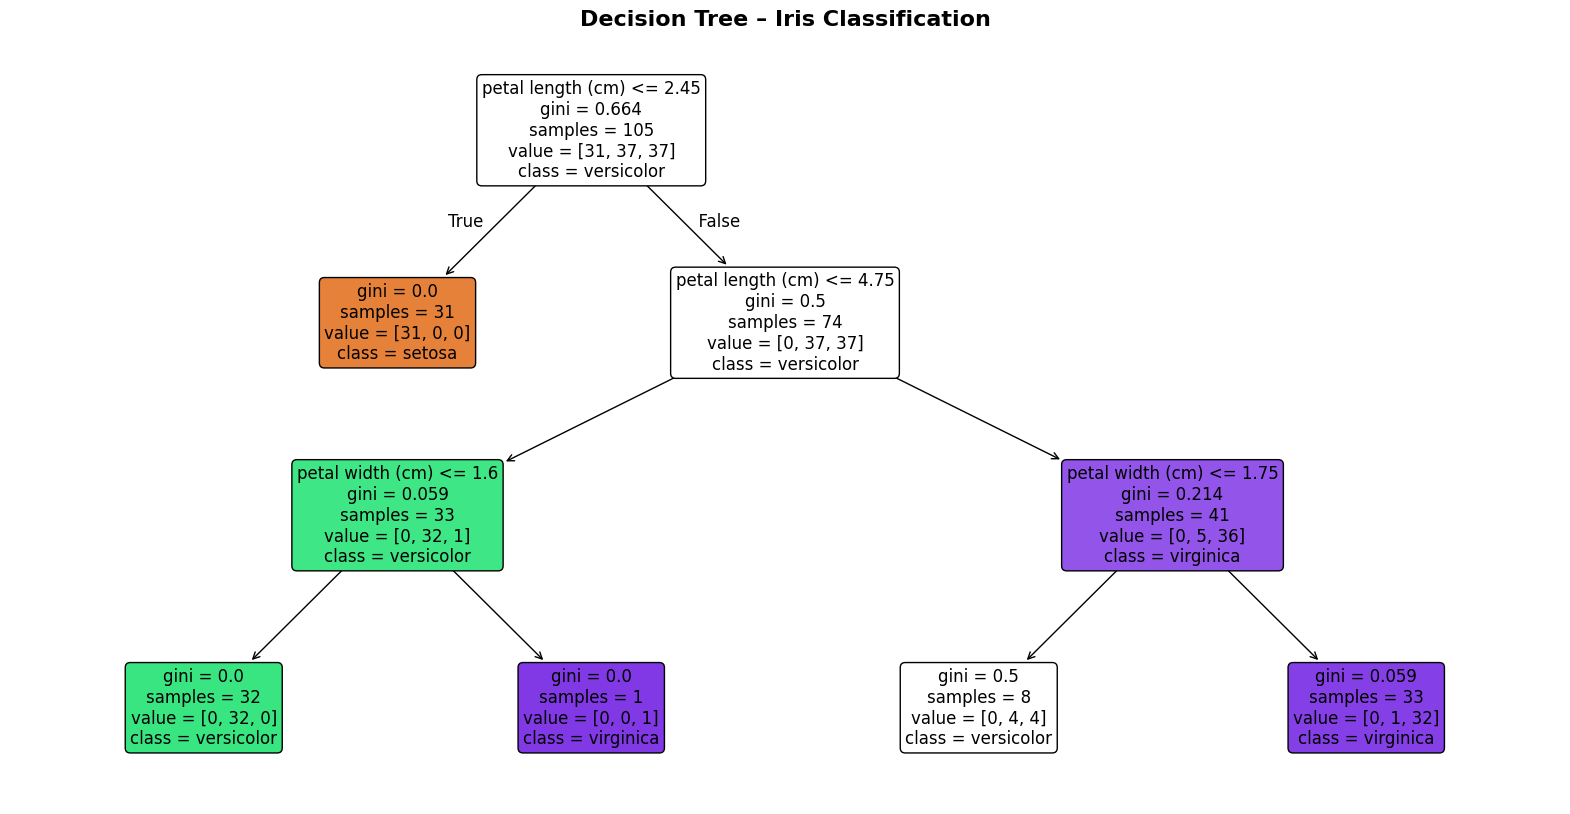

Node interpretation:
• Color: Majority class (darker = more pure)
• Gini: Impurity (0 = pure, 0.5 = mixed)
• samples: Training samples in node
• value: [class_0, class_1, class_2] counts


In [6]:
plt.figure(figsize=(20, 10))

plot_tree(tree,
          filled=True,
          feature_names=feature_names,
          class_names=list(class_names),
          rounded=True,
          fontsize=12)
plt.title('Decision Tree – Iris Classification', fontsize=16, fontweight='bold')
plt.show()
print('Node interpretation:')
print('• Color: Majority class (darker = more pure)')
print('• Gini: Impurity (0 = pure, 0.5 = mixed)')
print('• samples: Training samples in node')
print('• value: [class_0, class_1, class_2] counts')

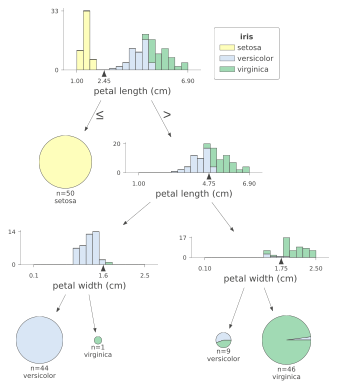

In [10]:
# dtreeviz visualization

# Re-defining dependencies due to kernel state issue:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

iris = load_iris()
x = iris.data
y = iris.target
feature_names = iris.feature_names
class_names = iris.target_names
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,
                                                    random_state=42)
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(x_train, y_train)

!pip install dtreeviz
!pip install graphviz
from dtreeviz import model as dtreeviz_model # Import 'model' as dtreeviz_model to avoid name clash with a local variable 'model'

viz_model = dtreeviz_model(
    tree,
    X_train=x,
    y_train=y,
    target_name='iris',
    feature_names=feature_names,
    class_names=list(class_names)
)
viz = viz_model.view()
display(viz)

FEATURE IMPORTANCE (Impurity-based)
sepal length (cm)        : 0.0000
sepal width (cm)         : 0.0000
petal width (cm)         : 0.0749
petal length (cm)        : 0.9251


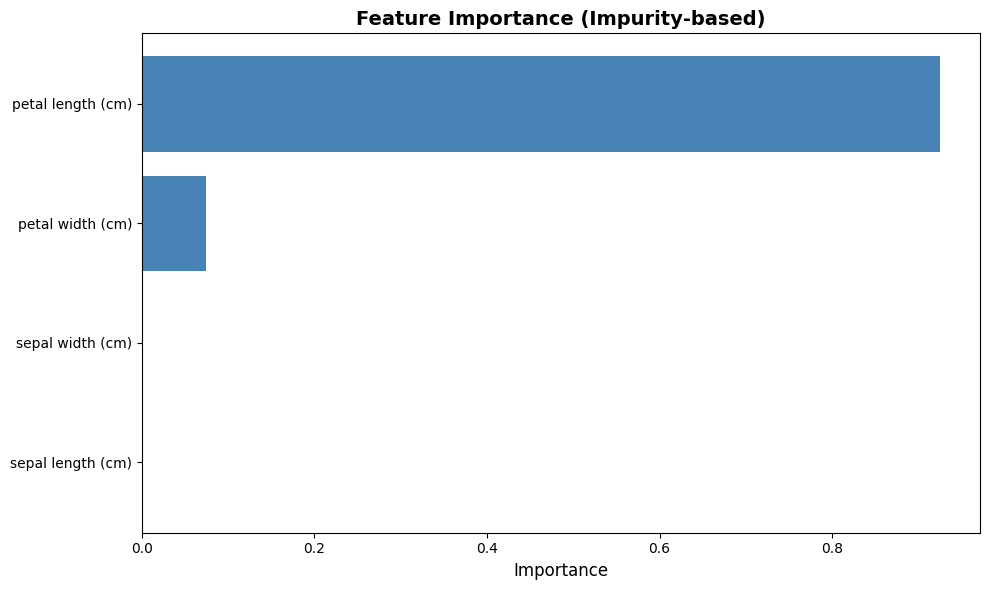

In [13]:
import numpy as np
import matplotlib.pyplot as plt

importances = tree.feature_importances_
indices = np.argsort(importances)[::1]

print('FEATURE IMPORTANCE (Impurity-based)')
print('='*50)
for i in indices:
    print(f'{feature_names[i]:25s}: {importances[i]:.4f}')
print('='*50)

plt.figure(figsize=(10, 6))
plt.barh(range(len(importances)), importances[indices], color='steelblue')
plt.yticks(range(len(importances)), [feature_names[i] for i in indices])
plt.xlabel('Importance', fontsize=12)
plt.title('Feature Importance (Impurity-based)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
from sklearn.inspection import permutation_importance
import numpy as np # Ensure numpy is imported

perm_importance = permutation_importance(
    tree, x_test, y_test, n_repeats=10, random_state=42
)

print('PERMUTATION IMPORTANCE (Test Set)')
print('='*50)
for i in np.argsort(perm_importance.importances_mean)[::-1]:
    print(f'{feature_names[i]:25s}: {perm_importance.importances_mean[i]:.4f} '
          f'± {perm_importance.importances_std[i]:.4f}')
print('='*50)

PERMUTATION IMPORTANCE (Test Set)
petal length (cm)        : 0.5200 ± 0.0912
petal width (cm)         : 0.3000 ± 0.0318
sepal width (cm)         : 0.0000 ± 0.0000
sepal length (cm)        : 0.0000 ± 0.0000



IMPORTANCE METHOD COMPARISON
          Feature  Impurity  Permutation
petal length (cm)  0.925108         0.52
 petal width (cm)  0.074892         0.30
 sepal width (cm)  0.000000         0.00
sepal length (cm)  0.000000         0.00


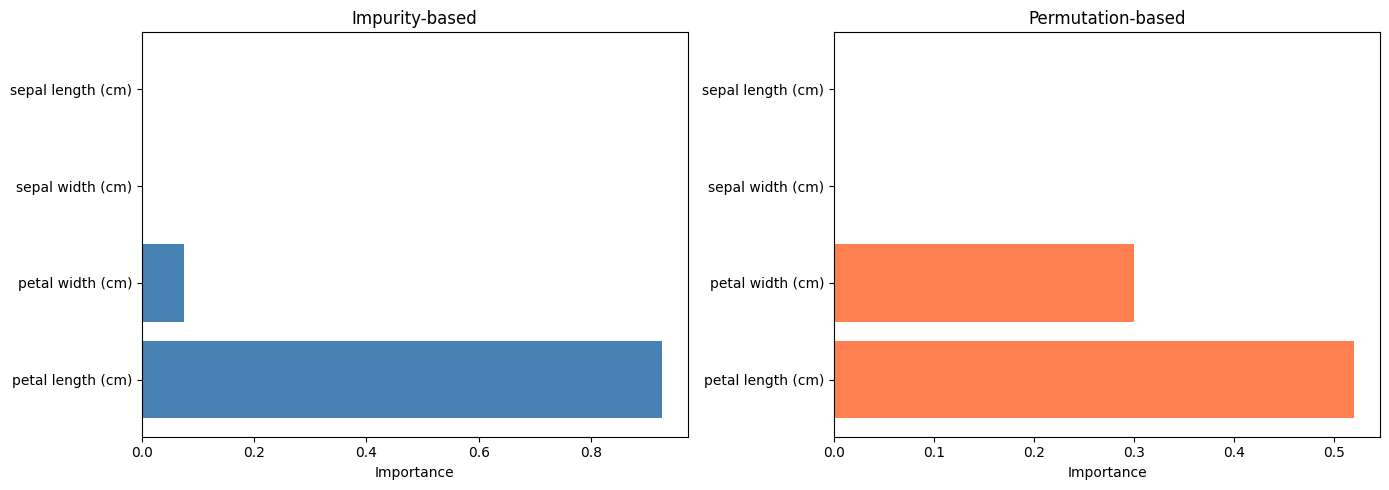

In [19]:
import pandas as pd

comparison_df = pd.DataFrame({
    'Feature': feature_names,
    'Impurity': importances,
    'Permutation': perm_importance.importances_mean
})

comparison_df = comparison_df.sort_values('Impurity', ascending=False)

print('\nIMPORTANCE METHOD COMPARISON')
print(comparison_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(comparison_df['Feature'], comparison_df['Impurity'],
             color='steelblue')
axes[0].set_xlabel('Importance')
axes[0].set_title('Impurity-based')

axes[1].barh(comparison_df['Feature'], comparison_df['Permutation'],
             color='coral')
axes[1].set_xlabel('Importance')
axes[1].set_title('Permutation-based')

plt.tight_layout()
plt.show()